Imports of packages

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import monai
import zarr
import nibabel as nib
from monai.data import DataLoader, Dataset
from pathlib import Path
from monai.networks.nets import DynUNet
from time import perf_counter as time
import pandas as pd
from skimage import measure
from scipy.ndimage import distance_transform_edt

## 1. Data

In [2]:
from scipy.ndimage import binary_dilation, zoom

IMAGE_NII     = Path("/work3/killeg/data/xray_1.nii")
SEG_NII       = Path("/zhome/d8/d/230907/me/meteorite/masks/ROI_total.nii.gz")
CLAST_LABELS = [1, 2, 3]

img_vol = nib.load(IMAGE_NII).get_fdata(dtype=np.float32)
seg_vol = nib.load(SEG_NII).get_fdata()

img_vol -= img_vol.min()
img_vol /= img_vol.max()

# seg_vol is at half the resolution of xray_1 — upsample 2× with nearest-neighbour
seg_vol = zoom(seg_vol, 2, order=0)

binary_seg = np.isin(seg_vol, CLAST_LABELS).astype(np.float32)
ROI_DILATION = 0
roi_mask   = binary_dilation(seg_vol != 0, iterations=ROI_DILATION).astype(np.float32)

print(f'img_vol shape : {img_vol.shape}')
print(f'seg_vol shape : {seg_vol.shape}')
print(f'Foreground    : {binary_seg.mean()*100:.2f}%')

img_vol shape : (1888, 360, 1450)
seg_vol shape : (1888, 360, 1450)
Foreground    : 2.29%


In [3]:
GOOD_START  = 202   # doubled from xray_2 value (101) — adjust if needed
GOOD_END    = 1680  # doubled from xray_2 value (840) — adjust if needed
BLOCK_SIZE  = 8
TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15
RANDOM_SEED = 35
CROP_SIZE   = (352, 1440)   # doubled from (176, 720), both divisible by 8

def center_crop(arr, h, w):
    H, W = arr.shape[-2], arr.shape[-1]
    y0 = (H - h) // 2
    x0 = (W - w) // 2
    return np.ascontiguousarray(arr[..., y0:y0+h, x0:x0+w])

rng = np.random.default_rng(RANDOM_SEED)
block_starts = np.arange(GOOD_START, GOOD_END, BLOCK_SIZE)
block_starts = block_starts[block_starts + BLOCK_SIZE <= GOOD_END]
rng.shuffle(block_starts)

n_blocks   = len(block_starts)
n_val      = max(1, round(n_blocks * VAL_FRAC))
n_test     = max(1, round(n_blocks * VAL_FRAC))
n_train    = n_blocks - n_val - n_test

train_blocks = sorted(block_starts[:n_train])
val_blocks   = sorted(block_starts[n_train:n_train + n_val])
test_blocks  = sorted(block_starts[n_train + n_val:])

train_idx = sorted([i for b in train_blocks for i in range(b, b + BLOCK_SIZE)])
val_idx   = sorted([i for b in val_blocks   for i in range(b, b + BLOCK_SIZE)])
test_idx  = sorted([i for b in test_blocks  for i in range(b, b + BLOCK_SIZE)])

def make_files(idx):
    return [{
        'image': center_crop(img_vol[i, :, :],    *CROP_SIZE)[None],
        'label': center_crop(binary_seg[i, :, :], *CROP_SIZE)[None],
        'roi':   center_crop(roi_mask[i, :, :],   *CROP_SIZE)[None],
    } for i in idx]

train_files = make_files(train_idx)
val_files   = make_files(val_idx)
test_files  = make_files(test_idx)

print(f'Blocks  — train: {n_train}  val: {n_val}  test: {n_test}')
print(f'Slices  — train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}')
print(f'Item shape — image: {train_files[0]["image"].shape}')

Blocks  — train: 128  val: 28  test: 28
Slices  — train: 1024  val: 224  test: 224
Item shape — image: (1, 352, 1440)


In [4]:
train_transforms = monai.transforms.Compose([
    monai.transforms.ScaleIntensityd(keys=['image']),
    monai.transforms.RandGaussianNoised(keys=['image'], prob=0.2, mean=0.0, std=0.02),
    monai.transforms.RandFlipd(keys=['image', 'label', 'roi'], prob=0.5, spatial_axis=0),
    monai.transforms.RandFlipd(keys=['image', 'label', 'roi'], prob=0.5, spatial_axis=1),
    monai.transforms.RandRotated(
        keys=['image', 'label', 'roi'], prob=0.2,
        range_x=0.3, range_y=0.0, range_z=0.0, mode=['bilinear', 'nearest', 'nearest'],
    ),
])

test_transforms = monai.transforms.Compose([
    monai.transforms.ScaleIntensityd(keys=['image']),
])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------------------------------------------------------
# Building block: two conv2d layers with a residual skip (GroupNorm + GELU)
# ---------------------------------------------------------------------------
class ResBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        groups = min(8, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.drop  = nn.Dropout2d(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        # 1x1 projection to match dims when in_ch != out_ch or stride > 1
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.GroupNorm(groups, out_ch),
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        h = F.gelu(self.norm1(self.conv1(x)))
        h = self.norm2(self.conv2(self.drop(h)))
        return F.gelu(h + self.skip(x))


# ---------------------------------------------------------------------------
# SSFB - Skip and Spatial Feature Blend (DALight-3D section 3.10, adapted to 2D)
#
# Inputs
#   f_dec : (B, dec_ch, H, W)  upsampled decoder features coming from below
#   f_enc : (B, enc_ch, H, W)  encoder skip features at the same resolution
#
# Two parallel pathways decide what to keep from the encoder skip:
#
#   1. Channel gate  (always active)
#      GAP(f_dec) and GAP(f_enc) concatenated -> MLP -> sigmoid
#      -> per-channel scalar that suppresses irrelevant encoder channels
#      o_gate = f_enc x sigma( MLP([GAP(f_dec) ; GAP(f_enc)]) )   (B, Ce, H, W)
#
#   2. Pooled spatial attention (only when pool_size is not None)
#      Q from decoder, K/V from encoder pooled to P x P positions.
#      Each decoder position attends over P^2 pooled enc keys -- O(N x P^2)
#      instead of O(N^2), making it tractable for large 2D maps.
#
#      pool_size=None  -> channel gate only   s0: 352x1440 = 506 K, P=2 is only 4 keys
#      pool_size=4     -> 16 pooled keys      s1: 176x720  = 127 K, A=(B,127K,16)= 32 MB
#      pool_size=8     -> 64 pooled keys      s2:  88x360  =  32 K, A=(B, 32K,64)= 32 MB
#
# Blend: m = sigma(alpha) * o_attn + (1 - sigma(alpha)) * o_gate
#         alpha is a learnable scalar initialised to 0 (equal blend at start)
#
# Output: GELU(GN(Conv3x3([f_dec ; m])))   shape (B, dec_ch, H, W)
# ---------------------------------------------------------------------------
class SSFB2D(nn.Module):
    def __init__(self, dec_ch, enc_ch, rank=8, pool_size=None):
        super().__init__()
        self.rank      = rank
        self.pool_size = pool_size
        groups = min(8, dec_ch)

        # Branch 1: channel gate
        hidden = max(4, (dec_ch + enc_ch) // 4)
        self.gate_mlp = nn.Sequential(
            nn.Linear(dec_ch + enc_ch, hidden),
            nn.GELU(),
            nn.Linear(hidden, enc_ch),
            nn.Sigmoid(),
        )

        # Branch 2: pooled spatial attention (only when pool_size is set)
        if pool_size is not None:
            self.q_proj   = nn.Conv2d(dec_ch, rank, 1, bias=False)
            self.k_proj   = nn.Conv2d(enc_ch, rank, 1, bias=False)
            self.v_proj   = nn.Conv2d(enc_ch, enc_ch, 1, bias=False)
            self.out_proj = nn.Conv2d(enc_ch, enc_ch, 1, bias=False)
            self.alpha    = nn.Parameter(torch.zeros(1))

        # Fusion: cat([f_dec, m]) -> conv -> dec_ch
        self.fuse = nn.Sequential(
            nn.Conv2d(dec_ch + enc_ch, dec_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, dec_ch),
            nn.GELU(),
        )

    def forward(self, f_dec, f_enc):
        B, Cd, H, W = f_dec.shape
        Ce           = f_enc.shape[1]

        # -- Branch 1: channel gate ------------------------------------------
        gap_dec = f_dec.mean(dim=[2, 3])                               # (B, Cd)
        gap_enc = f_enc.mean(dim=[2, 3])                               # (B, Ce)
        gate    = self.gate_mlp(torch.cat([gap_dec, gap_enc], dim=1))  # (B, Ce)
        o_gate  = f_enc * gate.view(B, Ce, 1, 1)                       # (B, Ce, H, W)

        # -- Branch 2: pooled spatial attention (deeper skips only) ----------
        if self.pool_size is not None:
            P  = self.pool_size
            Q  = self.q_proj(f_dec)                 # (B, rank, H, W)
            K  = self.k_proj(f_enc)                 # (B, rank, H, W)
            V  = self.v_proj(f_enc)                 # (B, Ce,   H, W)

            # Pool enc K/V to P x P -- goes from N positions down to P^2
            Kp = F.adaptive_avg_pool2d(K, (P, P))   # (B, rank, P, P)
            Vp = F.adaptive_avg_pool2d(V, (P, P))   # (B, Ce,   P, P)

            q  = Q.flatten(2).permute(0, 2, 1)      # (B, N,   rank)
            k  = Kp.flatten(2)                       # (B, rank, P^2)
            v  = Vp.flatten(2).permute(0, 2, 1)     # (B, P^2, Ce)

            # Each of N decoder positions attends over P^2 encoder positions
            A      = torch.softmax(q @ k / (self.rank ** 0.5), dim=-1)  # (B, N, P^2)
            o_flat = A @ v                                                # (B, N, Ce)
            o_attn = o_flat.permute(0, 2, 1).reshape(B, Ce, H, W)       # (B, Ce, H, W)
            o_attn = self.out_proj(o_attn)                               # (B, Ce, H, W)

            alpha  = torch.sigmoid(self.alpha)                           # scalar in (0,1)
            m      = alpha * o_attn + (1 - alpha) * o_gate              # (B, Ce, H, W)
        else:
            m = o_gate

        # -- Fuse: concat dec + blended enc -> conv -> dec_ch ----------------
        return self.fuse(torch.cat([f_dec, m], dim=1))                  # (B, Cd, H, W)


# ---------------------------------------------------------------------------
# SSFBUNet2D — 2D U-Net with SSFB skip connections
#
# Mirrors DynUNet(strides=[1,2,2,2], filters=[32,64,128,256]) but replaces
# naive skip concatenation with SSFB.
#
# For CROP_SIZE = (352, 1440):
#
#   Input              (B,   1, 352, 1440)
#   enc0  stride=1     (B,  32, 352, 1440)  <- skip s0  channel gate only (N=507 K)
#   enc1  stride=2     (B,  64, 176,  720)  <- skip s1  gate + attn P=4   (N=127 K)
#   enc2  stride=2     (B, 128,  88,  360)  <- skip s2  gate + attn P=8   (N= 32 K)
#   bottleneck str=2   (B, 256,  44,  180)
#   up2 x2             (B, 128,  88,  360)  -> SSFB(dec=128, enc=128)
#   up1 x2             (B,  64, 176,  720)  -> SSFB(dec= 64, enc= 64)
#   up0 x2             (B,  32, 352, 1440)  -> SSFB(dec= 32, enc= 32)
#   head 1x1           (B,   1, 352, 1440)  -> binary logit
#
# Attention budget at B=4 (float32):
#   s2 P=8: A = (4, 31680, 64) =  32 MB
#   s1 P=4: A = (4,126720, 16) =  32 MB
#   s0 None: channel gate only  -- P=2 would give only 4 pooled keys, not useful
# ---------------------------------------------------------------------------
class SSFBUNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, dropout=0.2):
        super().__init__()
        ch = [32, 64, 128, 256]

        # -- Encoder ----------------------------------------------------------
        self.enc0       = ResBlock2D(in_channels, ch[0], stride=1, dropout=dropout)
        self.enc1       = ResBlock2D(ch[0], ch[1], stride=2, dropout=dropout)
        self.enc2       = ResBlock2D(ch[1], ch[2], stride=2, dropout=dropout)
        self.bottleneck = ResBlock2D(ch[2], ch[3], stride=2, dropout=dropout)

        # -- Upsampling -------------------------------------------------------
        self.up2 = nn.ConvTranspose2d(ch[3], ch[2], kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose2d(ch[2], ch[1], kernel_size=2, stride=2)
        self.up0 = nn.ConvTranspose2d(ch[1], ch[0], kernel_size=2, stride=2)

        # -- SSFB skip fusion -------------------------------------------------
        self.ssfb2 = SSFB2D(dec_ch=ch[2], enc_ch=ch[2], rank=8, pool_size=8)
        self.ssfb1 = SSFB2D(dec_ch=ch[1], enc_ch=ch[1], rank=8, pool_size=4)
        self.ssfb0 = SSFB2D(dec_ch=ch[0], enc_ch=ch[0], rank=8, pool_size=None)

        # -- Output head ------------------------------------------------------
        self.head = nn.Conv2d(ch[0], out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        s0 = self.enc0(x)           # (B,  32, 352, 1440)
        s1 = self.enc1(s0)          # (B,  64, 176,  720)
        s2 = self.enc2(s1)          # (B, 128,  88,  360)
        z  = self.bottleneck(s2)    # (B, 256,  44,  180)

        # Decoder + SSFB
        d2 = self.ssfb2(self.up2(z),  s2)   # (B, 128,  88,  360)
        d1 = self.ssfb1(self.up1(d2), s1)   # (B,  64, 176,  720)
        d0 = self.ssfb0(self.up0(d1), s0)   # (B,  32, 352, 1440)

        return self.head(d0)                 # (B,   1, 352, 1440)


model = SSFBUNet2D(in_channels=1, out_channels=1, dropout=0.2)

# Dice loss only (no CE), sigmoid applied inside the loss.
# -20.0 ROI mask logits become ~0 after sigmoid, keeping the Dice denominator valid.
loss_fn   = monai.losses.DiceCELoss(sigmoid=True, lambda_dice=1.0, lambda_ce=0.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)


In [6]:
USE_MODEL_CHECKPOINT = False
checkpoint_file = "/zhome/d8/d/230907/me/meteorite/weights/model_2d_tvt_xray1_copy.pth"

if USE_MODEL_CHECKPOINT:
    checkpoint = torch.load(checkpoint_file)
    model.load_state_dict(checkpoint['model'])

In [7]:
NUM_EPOCHS = 50

train_loader = DataLoader(
    Dataset(data=train_files, transform=train_transforms),
    batch_size=4, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True,
)
val_loader = DataLoader(
    Dataset(data=val_files, transform=test_transforms),
    batch_size=4, shuffle=False,
)

model     = model.cuda()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

if USE_MODEL_CHECKPOINT:
    all_train_losses = checkpoint['train_losses']
    all_val_losses   = checkpoint['val_losses']
    best_val_loss    = np.min(checkpoint['val_losses'])
else:
    all_train_losses = []
    all_val_losses   = []
    best_val_loss    = float('inf')

for epoch in range(NUM_EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    epoch_loss, steps = 0, 0
    for batch in train_loader:
        inputs  = batch['image'].cuda(non_blocking=True)
        targets = batch['label'].cuda(non_blocking=True).float()
        roi     = batch['roi'].cuda(non_blocking=True)
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = torch.where(roi.expand_as(outputs) > 0, outputs, torch.full_like(outputs, -20.0))
        loss    = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.detach()
        steps += 1
    train_loss = epoch_loss.item() / steps
    all_train_losses.append(train_loss)
    scheduler.step()

    # ── Validation ─────────────────────────────────────────────────────────
    model.eval()
    epoch_loss, steps = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            inputs  = batch['image'].cuda(non_blocking=True)
            targets = batch['label'].cuda(non_blocking=True).float()
            roi     = batch['roi'].cuda(non_blocking=True)
            outputs = model(inputs)
            outputs = torch.where(roi.expand_as(outputs) > 0, outputs, torch.full_like(outputs, -20.0))
            epoch_loss += loss_fn(outputs, targets).detach()
            steps += 1
    val_loss = epoch_loss.item() / steps
    all_val_losses.append(val_loss)

    # Save on best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
            'epoch': epoch, 'train_losses': all_train_losses, 'val_losses': all_val_losses,
        }, checkpoint_file)
        print(f'  -> Saved (val loss: {val_loss:.4f})')

    print(f'Epoch {epoch+1:3d}  train={train_loss:.4f}  val={val_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}')


  -> Saved (val loss: 0.4556)
Epoch   1  train=0.7976  val=0.4556  lr=9.99e-04
  -> Saved (val loss: 0.4280)
Epoch   2  train=0.7554  val=0.4280  lr=9.96e-04
Epoch   3  train=0.7517  val=0.4338  lr=9.91e-04
  -> Saved (val loss: 0.4174)
Epoch   4  train=0.7499  val=0.4174  lr=9.84e-04
Epoch   5  train=0.7484  val=0.4181  lr=9.76e-04
  -> Saved (val loss: 0.3811)
Epoch   6  train=0.7470  val=0.3811  lr=9.65e-04
Epoch   7  train=0.7456  val=0.4386  lr=9.52e-04
Epoch   8  train=0.7457  val=0.4130  lr=9.38e-04
Epoch   9  train=0.7446  val=0.3950  lr=9.22e-04
Epoch  10  train=0.7444  val=0.4354  lr=9.05e-04
Epoch  11  train=0.7435  val=0.4592  lr=8.85e-04
Epoch  12  train=0.7433  val=0.4205  lr=8.64e-04
Epoch  13  train=0.7429  val=0.4149  lr=8.42e-04
Epoch  14  train=0.7423  val=0.4218  lr=8.19e-04
Epoch  15  train=0.7425  val=0.3896  lr=7.94e-04
Epoch  16  train=0.7419  val=0.4130  lr=7.68e-04
Epoch  17  train=0.7413  val=0.4462  lr=7.41e-04
Epoch  18  train=0.7411  val=0.4124  lr=7.13e-0

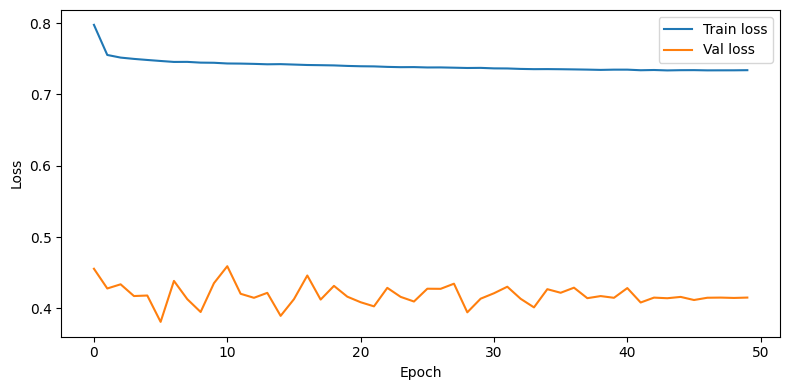

Best val loss: 0.3811 at epoch 6


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(all_train_losses, label='Train loss')
ax.plot(all_val_losses,   label='Val loss')
#ax.axvline(x=np.argmin(all_val_losses), color='grey', linestyle='--', label='Best val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Best val loss: {min(all_val_losses):.4f} at epoch {np.argmin(all_val_losses)+1}')


In [9]:
# Load best checkpoint and evaluate on held-out test set
checkpoint = torch.load(checkpoint_file)
model.load_state_dict(checkpoint['model'])
model.eval()

test_loader = DataLoader(
    Dataset(data=test_files, transform=test_transforms),
    batch_size=4, shuffle=False,
)

def dice(pred, gt):
    return 2*(pred*gt).sum() / (pred.sum() + gt.sum() + 1e-8)

all_tp, all_fp, all_fn = 0, 0, 0
with torch.no_grad():
    for batch in test_loader:
        inputs  = batch['image'].cuda(non_blocking=True)
        targets = batch['label'].cuda(non_blocking=True).float()
        roi     = batch['roi'].cuda(non_blocking=True)
        outputs = model(inputs)
        outputs = torch.where(roi.expand_as(outputs) > 0, outputs, torch.full_like(outputs, -20.0))
        pred    = (torch.sigmoid(outputs) > 0.5).float()
        all_tp += (pred * targets).sum().item()
        all_fp += (pred * (1 - targets)).sum().item()
        all_fn += ((1 - pred) * targets).sum().item()

test_dice = 2*all_tp / (2*all_tp + all_fp + all_fn + 1e-8)
print(f'Test Dice : {test_dice:.4f}')
print(f'Best epoch: {checkpoint["epoch"]+1}  (val loss {min(all_val_losses):.4f})')


Test Dice : 0.6111
Best epoch: 6  (val loss 0.3811)


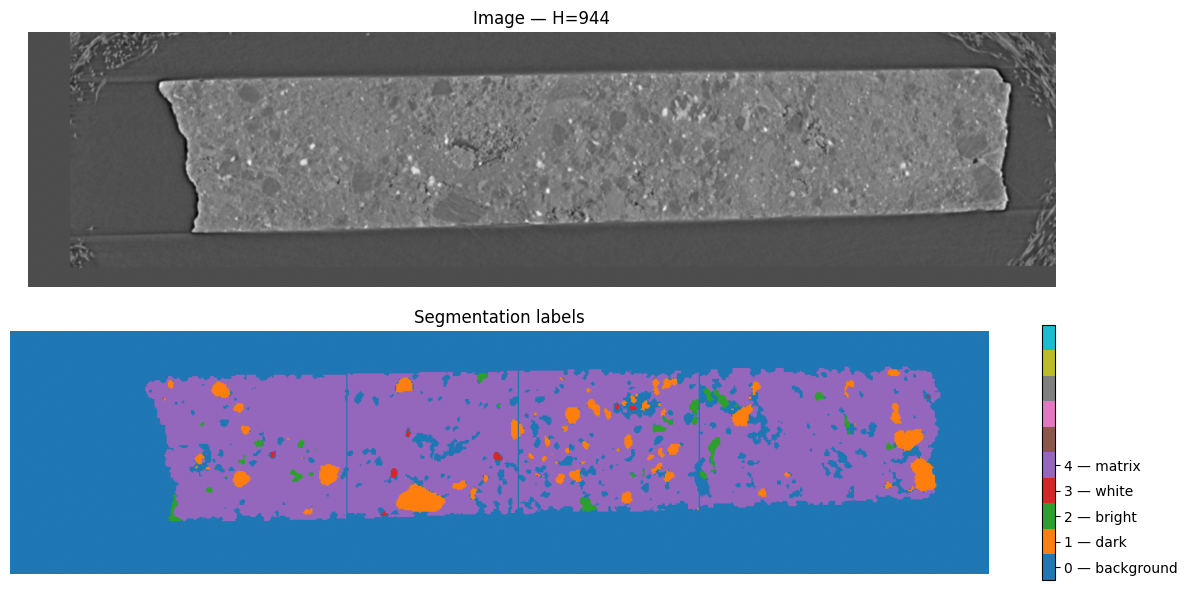

In [10]:
SLICE_H = img_vol.shape[0] // 2   # <-- change this

s = img_vol[SLICE_H, :, :]
m = seg_vol[SLICE_H, :, :]

LABEL_NAMES = {0: 'background', 1: 'dark', 2: 'bright', 3: 'white', 4: 'matrix'}

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].imshow(s, cmap='gray'); axes[0].set_title(f'Image — H={SLICE_H}'); axes[0].axis('off')
im = axes[1].imshow(m, cmap='tab10', vmin=-0.5, vmax=9.5)
axes[1].set_title('Segmentation labels'); axes[1].axis('off')
cb = plt.colorbar(im, ax=axes[1], fraction=0.03)
present = sorted(np.unique(m).astype(int))
cb.set_ticks(present)
cb.set_ticklabels([f'{l} — {LABEL_NAMES.get(l, "?")}' for l in present])
plt.tight_layout(); plt.show()

In [11]:
import ipywidgets as widgets

model.eval()
pred_vol = np.zeros((img_vol.shape[0], img_vol.shape[1], img_vol.shape[2]))//2  # (H, D, W)

with torch.no_grad():
    for i in range(img_vol.shape[0]):
        sl  = img_vol[i, :, :]
        sl  = (sl - sl.min()) / (sl.max() - sl.min() + 1e-8)
        inp = torch.from_numpy(sl[None, None]).float().cuda()   # (1, 1, D, W)
        logits = monai.inferers.sliding_window_inference(
            inp, CROP_SIZE, sw_batch_size=1, predictor=model, overlap=0.25,
        )
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()   # (D, W)
        pred_vol[i] = probs * roi_mask[i, :, :]

def show(i):
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    axes[0].imshow(img_vol[i, :, :], cmap='gray'); axes[0].set_title(f'H={i}'); axes[0].axis('off')
    axes[1].imshow(img_vol[i, :, :], cmap='gray')
    p = pred_vol[i]
    axes[1].imshow(np.where(p > 0.05, p, np.nan), cmap='Reds', alpha=0.5, vmin=0, vmax=1)
    axes[1].set_title('Prediction (opacity=probability)'); axes[1].axis('off')
    plt.tight_layout(); plt.show()

widgets.interact(show, i=widgets.IntSlider(min=0, max=img_vol.shape[0]-1, step=1, value=img_vol.shape[0]//2))


/dtu/3d-imaging-center/courses/02510/groups/killian/gpu_env/lib/python3.11/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/dtu/3d-imaging-center/courses/02510/groups/killian/gpu_env/lib/python3.11/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch

interactive(children=(IntSlider(value=944, description='i', max=1887), Output()), _dom_classes=('widget-intera…

<function __main__.show(i)>

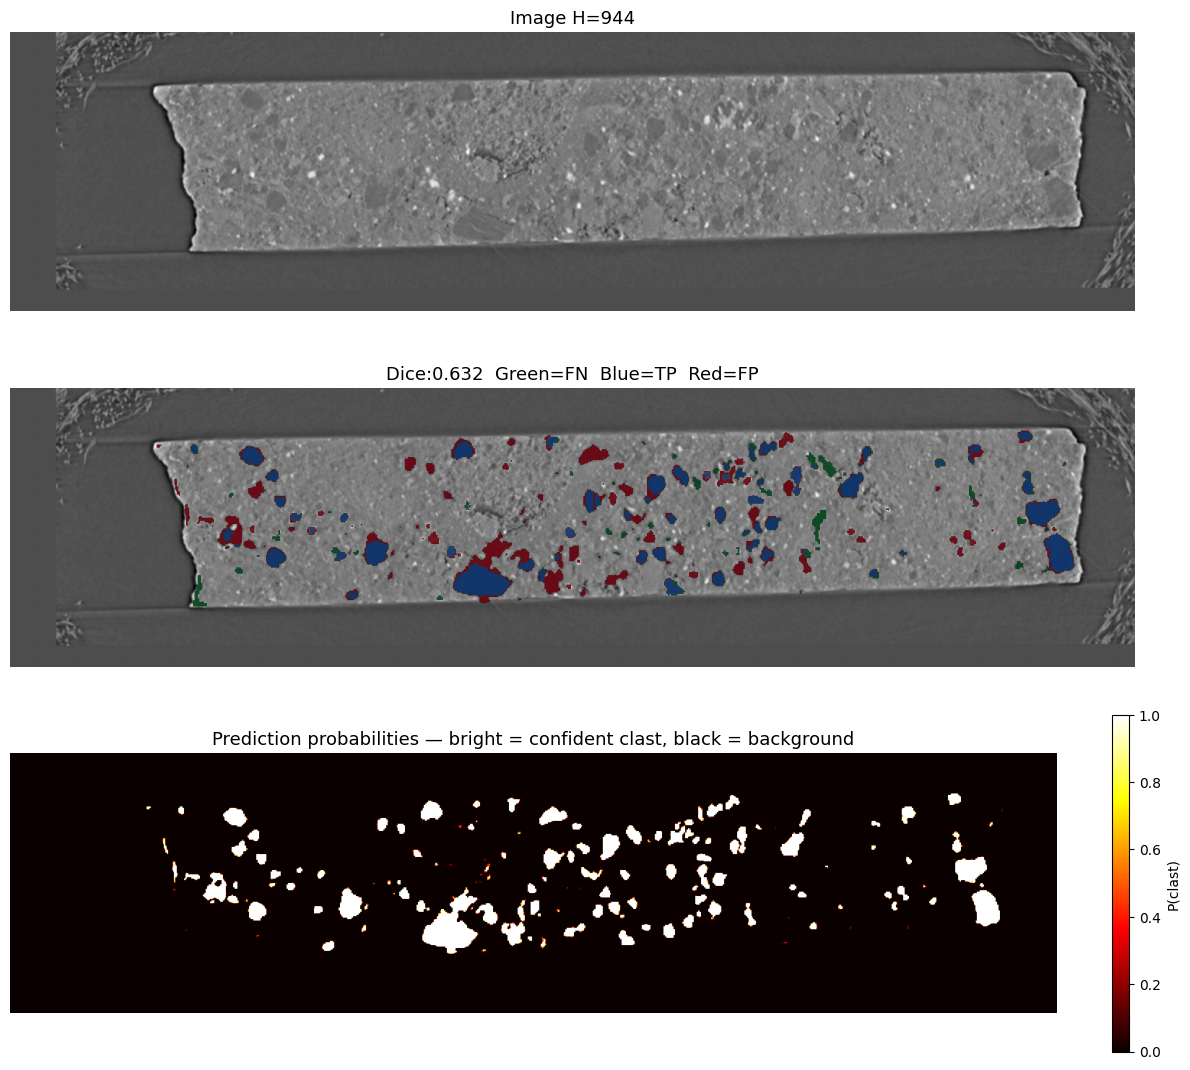

In [12]:
SLICE_H = img_vol.shape[0] // 2   # <-- change this

img   = img_vol[SLICE_H, :, :]
gt    = binary_seg[SLICE_H, :, :]
probs = pred_vol[SLICE_H]           # raw probabilities [0, 1]
pred  = probs > 0.5

fn_mask = (gt == 1) & (pred == 0)   # missed       → green
tp_mask = (gt == 1) & (pred == 1)   # correct      → blue
fp_mask = (gt == 0) & (pred == 1)   # false pos    → red

fig, axes = plt.subplots(3, 1, figsize=(12, 11))

# Top: original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f'Image H={SLICE_H}', fontsize=13); axes[0].axis('off')

# Middle: GT vs prediction overlay
axes[1].imshow(img, cmap='gray')
axes[1].imshow(np.where(fn_mask, 1, np.nan), cmap='Greens', alpha=0.9, vmin=0, vmax=1)
axes[1].imshow(np.where(tp_mask, 1, np.nan), cmap='Blues',  alpha=0.9, vmin=0, vmax=1)
axes[1].imshow(np.where(fp_mask, 1, np.nan), cmap='Reds',   alpha=0.9, vmin=0, vmax=1)
n_tp = int(tp_mask.sum()); n_fp = int(fp_mask.sum()); n_fn = int(fn_mask.sum())
d = 2*n_tp / (2*n_tp + n_fp + n_fn + 1e-8)
axes[1].set_title(f'Dice:{d:.3f}  Green=FN  Blue=TP  Red=FP', fontsize=13); axes[1].axis('off')

# Bottom: raw probability heatmap (no gray underlay — pure heatmap so values are readable)
im = axes[2].imshow(probs, cmap='hot', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[2], fraction=0.02, label='P(clast)')
axes[2].set_title('Prediction probabilities — bright = confident clast, black = background', fontsize=13)
axes[2].axis('off')

plt.tight_layout(); plt.show()


In [13]:
def dice(pred, gt):
    return 2*(pred*gt).sum() / (pred.sum() + gt.sum() + 1e-8)

pred_bin  = pred_vol > 0.5 # change value 
train_pred = np.stack([pred_bin[i]    for i in train_idx])
train_gt   = np.stack([binary_seg[i]  for i in train_idx])
test_pred  = np.stack([pred_bin[i]    for i in test_idx])
test_gt    = np.stack([binary_seg[i]  for i in test_idx])
print(f'Dice — train: {dice(train_pred, train_gt):.4f}  test: {dice(test_pred, test_gt):.4f}')


Dice — train: 0.6080  test: 0.6041
